<a href="https://colab.research.google.com/github/rohanbhangale/mldl_exps/blob/main/mldl_exp_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 219s 553ms/step - loss: 0.5858 - val_loss: 0.5791
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 227s 580ms/step - loss: 0.5747 - val_loss: 0.5750
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 252s 554ms/step - loss: 0.5731 - val_loss: 0.5741
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 216s 553ms/step - loss: 0.5723 - val_loss: 0.5725
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 263s 556ms/step - loss: 0.5717 - val_loss: 0.5721
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step


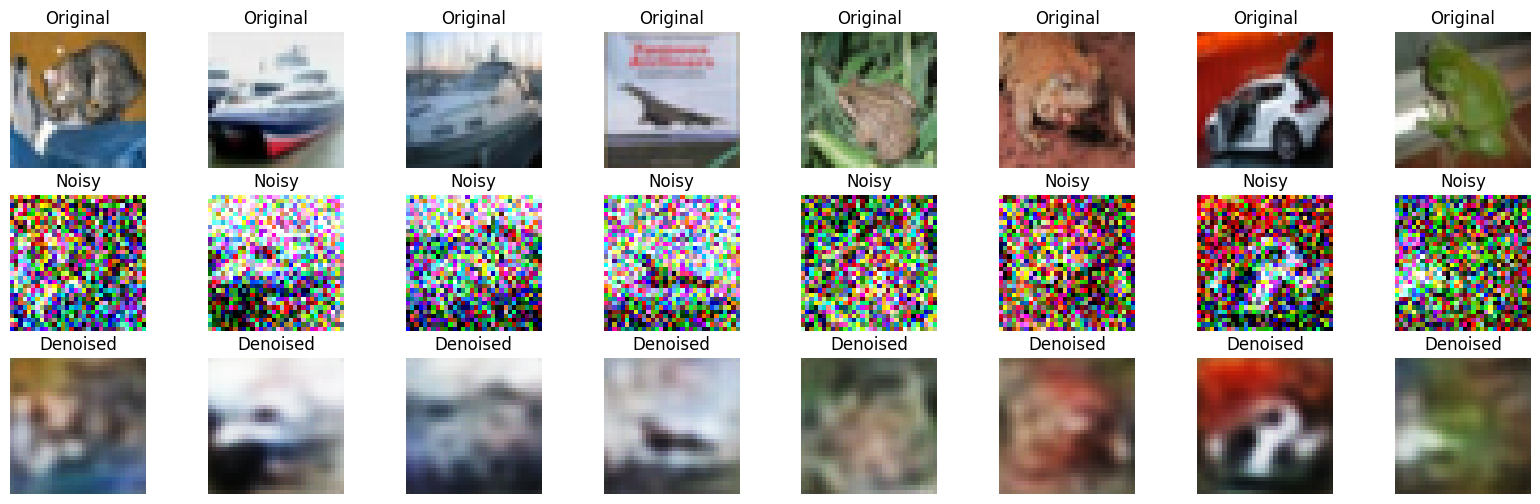

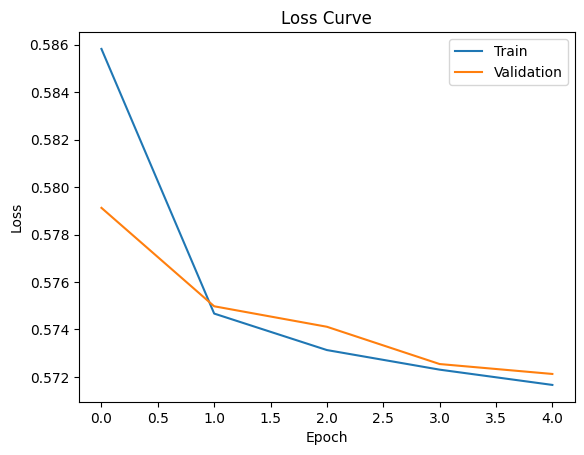

In [1]:
# =========================================
# AUTOENCODER (DENOISING) - CIFAR-10
# =========================================

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

# =========================================
# STEP 1: LOAD DATA
# =========================================

(x_train, _), (x_test, _) = cifar10.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# =========================================
# STEP 2: ADD NOISE
# =========================================

noise_factor = 0.4

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# =========================================
# STEP 3: BUILD CONVOLUTIONAL AUTOENCODER
# =========================================

input_img = Input(shape=(32, 32, 3))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

# Model
autoencoder = Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.summary()

# =========================================
# STEP 4: TRAIN MODEL
# =========================================

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=5,
    batch_size=128,
    validation_data=(x_test_noisy, x_test)
)

# =========================================
# STEP 5: PREDICTION
# =========================================

denoised = autoencoder.predict(x_test_noisy)

# =========================================
# STEP 6: VISUALIZATION
# =========================================

n = 8
plt.figure(figsize=(20,6))

# ORIGINAL
for i in range(n):
    ax = plt.subplot(3, n, i+1)
    plt.imshow(x_test[i])
    plt.title("Original")
    plt.axis('off')

# NOISY
for i in range(n):
    ax = plt.subplot(3, n, i+n+1)
    plt.imshow(x_test_noisy[i])
    plt.title("Noisy")
    plt.axis('off')

# DENOISED
for i in range(n):
    ax = plt.subplot(3, n, i+2*n+1)
    plt.imshow(denoised[i])
    plt.title("Denoised")
    plt.axis('off')

plt.show()

# =========================================
# STEP 7: LOSS GRAPH
# =========================================

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()